In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

In [104]:
keras.utils.set_random_seed(42)

In [105]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [106]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [107]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

In [108]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

In [109]:
df = pd.get_dummies(df, columns=categorical_variables)

In [110]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [111]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [112]:
mean = train_df[numerics].mean()
std = train_df[numerics].std()
train_df[numerics] = (train_df[numerics] - mean) / std

In [113]:
mean = test_df[numerics].mean()
std = test_df[numerics].std()
test_df[numerics] = (test_df[numerics] - mean) / std

In [114]:
train_X = train_df.drop("target", axis=1).astype("float32").to_numpy()
train_y = train_df["target"].astype("float32").to_numpy()

test_X = test_df.drop("target", axis=1).astype("float32").to_numpy()
test_y = test_df["target"].astype("float32").to_numpy()

In [115]:
train_X.shape, test_X.shape,train_y.shape, test_y.shape

((242, 29), (61, 29), (242,), (61,))

In [116]:
num = train_X.shape[1]

input = keras.Input(shape=(num,))
x = keras.layers.Dense(32, activation="relu")(input)
output = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(input, output)

In [117]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
keras.utils.plot_model(model, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [119]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [120]:
history = model.fit(train_X,
                    train_y,
                    epochs=300,
                    batch_size=16,
                    verbose=1,
                    validation_split=0.2)

Epoch 1/300


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3731 - loss: 0.7727 - val_accuracy: 0.5102 - val_loss: 0.7128
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5648 - loss: 0.6908 - val_accuracy: 0.6531 - val_loss: 0.6681
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6788 - loss: 0.6316 - val_accuracy: 0.6735 - val_loss: 0.6326
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7306 - loss: 0.5825 - val_accuracy: 0.6939 - val_loss: 0.6026
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7565 - loss: 0.5407 - val_accuracy: 0.7347 - val_loss: 0.5766
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7824 - loss: 0.5040 - val_accuracy: 0.7551 - val_loss: 0.5536
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7927 - loss: 0.4716 - val_accuracy: 0.7551 - val_loss: 0.5331
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8083 - loss: 0.4429 - val_accuracy: 0.7755 - val_loss: 0

In [121]:

history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

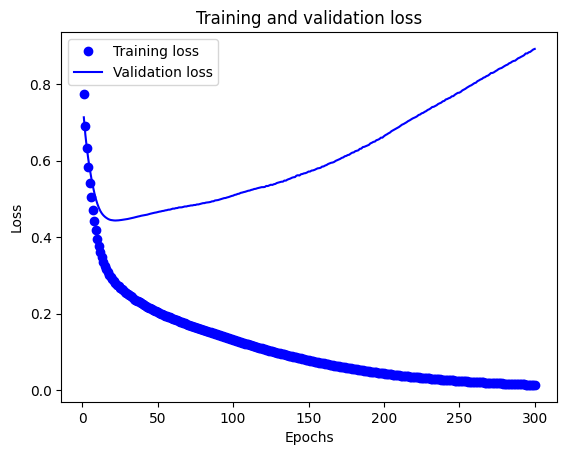

In [122]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

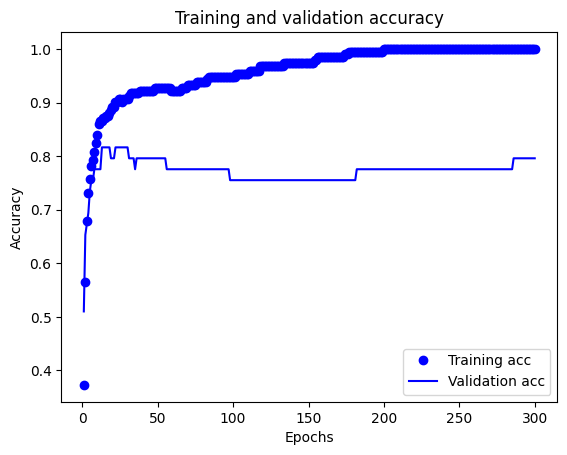

In [123]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [124]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8361 - loss: 0.6736


[0.6735559701919556, 0.8360655903816223]